### First Data analytic Project

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
df = pd.read_csv('Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


### Data Over-view

In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [65]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [66]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

## EDA


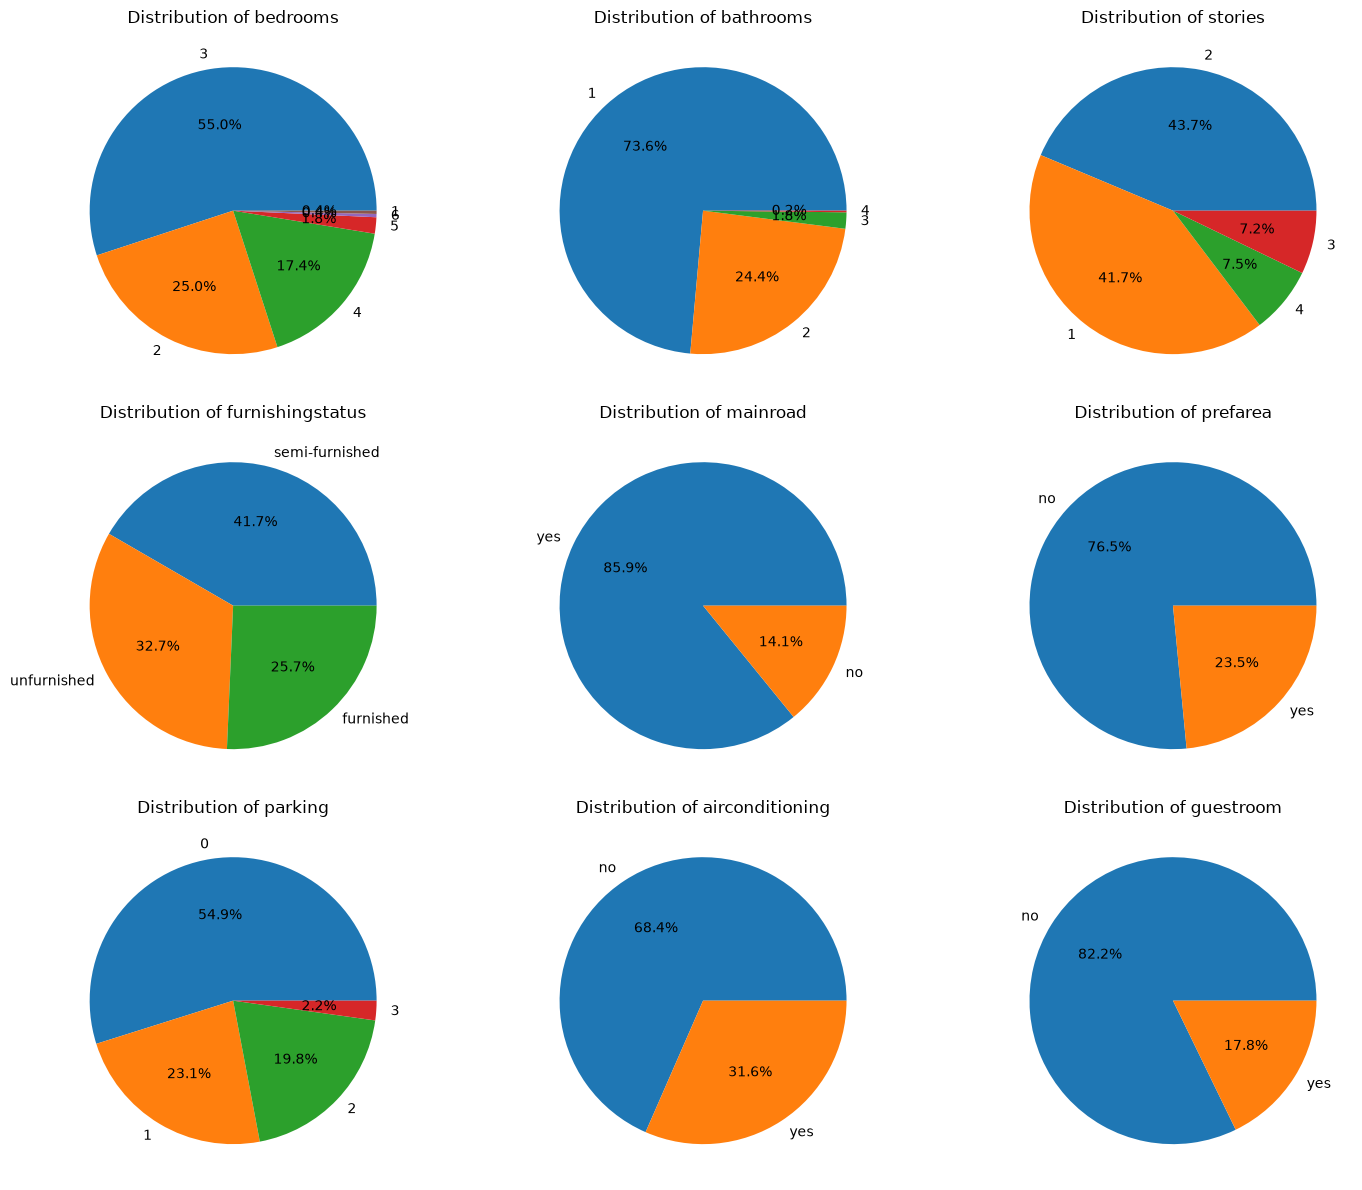

In [67]:
fig , axes = plt.subplots(3,3, figsize=(15, 12))


axes[0,0].pie(df['bedrooms'].value_counts(), labels=df['bedrooms'].value_counts().index , autopct="%1.1f%%")
axes[0,0].set_title("Distribution of bedrooms") 

axes[0,1].pie(df['bathrooms'].value_counts(), labels=df['bathrooms'].value_counts().index , autopct="%1.1f%%")
axes[0,1].set_title("Distribution of bathrooms")

axes[0,2].pie(df['stories'].value_counts(), labels=df['stories'].value_counts().index , autopct="%1.1f%%")
axes[0,2].set_title("Distribution of stories")

axes[1,0].pie(df['furnishingstatus'].value_counts(), labels=df['furnishingstatus'].value_counts().index , autopct="%1.1f%%")
axes[1,0].set_title("Distribution of furnishingstatus")

axes[1,1].pie(df['mainroad'].value_counts(), labels=df['mainroad'].value_counts().index , autopct="%1.1f%%")
axes[1,1].set_title("Distribution of mainroad")

axes[1,2].pie(df['prefarea'].value_counts(), labels=df['prefarea'].value_counts().index , autopct="%1.1f%%")
axes[1,2].set_title("Distribution of prefarea")

axes[2,0].pie(df['parking'].value_counts(), labels=df['parking'].value_counts().index , autopct="%1.1f%%")
axes[2,0].set_title("Distribution of parking")

axes[2,1].pie(df['airconditioning'].value_counts(), labels=df['airconditioning'].value_counts().index , autopct="%1.1f%%")
axes[2,1].set_title("Distribution of airconditioning")

axes[2,2].pie(df['guestroom'].value_counts(), labels=df['guestroom'].value_counts().index , autopct="%1.1f%%")
axes[2,2].set_title("Distribution of guestroom")

plt.tight_layout()
plt.show()



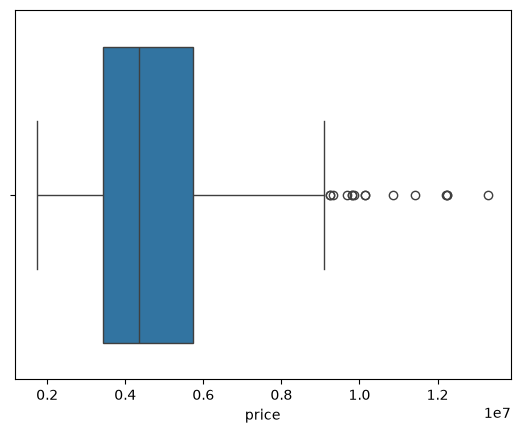

In [68]:
sns.boxplot(x=df['price'])
plt.show()


<Axes: xlabel='price', ylabel='area'>

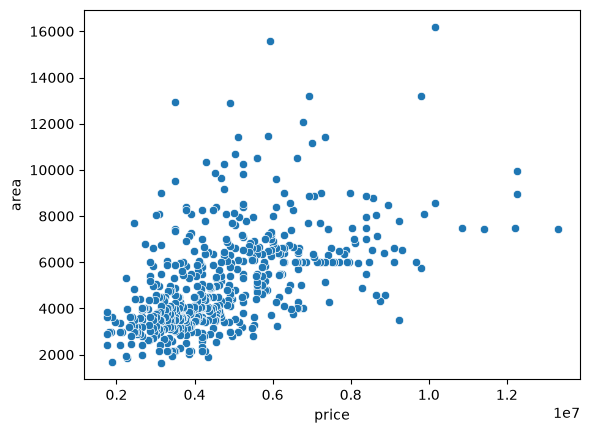

In [69]:
sns.scatterplot(x=df['price'], y=df['area'])

Data Cleaning & preparing 

In [70]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [71]:
percentiles = df['price'].quantile([0.25, 0.5, 0.75])
print(percentiles)

0.25    3430000.0
0.50    4340000.0
0.75    5740000.0
Name: price, dtype: float64


In [72]:
iqr = percentiles[0.75] - percentiles[0.25]
lower_bound = percentiles[0.25] - 1.5 * iqr
upper_bound = percentiles[0.75] + 1.5 * iqr
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

Lower Bound: -35000.0
Upper Bound: 9205000.0


In [73]:
df = df[df['price'] < upper_bound]
df.shape

(530, 13)

In [74]:
lst = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

In [75]:
def func(lst):
    for i in lst:
        df[i] = df[i].map({'yes': 1, 'no': 0})
    return df

func(lst)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
15,9100000,6000,4,1,2,1,0,1,0,0,2,0,semi-furnished
16,9100000,6600,4,2,2,1,1,1,0,1,1,1,unfurnished
17,8960000,8500,3,2,4,1,0,0,0,1,2,0,furnished
18,8890000,4600,3,2,2,1,1,0,0,1,2,0,furnished
19,8855000,6420,3,2,2,1,0,0,0,1,1,1,semi-furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,unfurnished
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,semi-furnished
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,unfurnished
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,furnished


In [76]:
df['furnishingstatus'] = df['furnishingstatus'].map({'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0})
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
15,9100000,6000,4,1,2,1,0,1,0,0,2,0,1
16,9100000,6600,4,2,2,1,1,1,0,1,1,1,0
17,8960000,8500,3,2,4,1,0,0,0,1,2,0,2
18,8890000,4600,3,2,2,1,1,0,0,1,2,0,2
19,8855000,6420,3,2,2,1,0,0,0,1,1,1,1


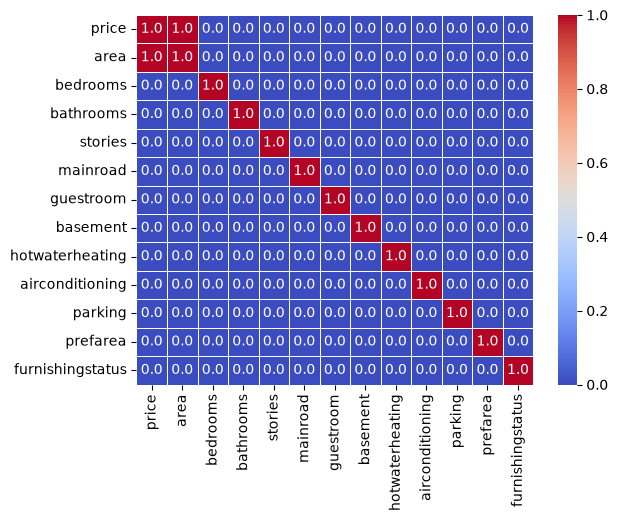

In [77]:
sns.heatmap(df.corr()>0.5, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".1f")
plt.show()

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [79]:
df


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
15,9100000,6000,4,1,2,1,0,1,0,0,2,0,1
16,9100000,6600,4,2,2,1,1,1,0,1,1,1,0
17,8960000,8500,3,2,4,1,0,0,0,1,2,0,2
18,8890000,4600,3,2,2,1,1,0,0,1,2,0,2
19,8855000,6420,3,2,2,1,0,0,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,2


In [80]:
target = df['price']
df = df.drop('price', axis=1)

In [ ]:


X_train, X_test, y_train, y_test = train_test_split(df, target, test_size=0.2, random_state=42)
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)
reg = RandomForestRegressor(n_estimators=200, random_state=42, criterion='squared_error', max_depth=10, min_samples_split=2, min_samples_leaf=1, bootstrap=True, n_jobs=-1)

reg.fit(X_train, y_train)

pred = reg.predict(X_test)

mse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred) 

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 1237227849289.8198
R-squared: 0.6426902524500904
